# Installing Dependencies

In [1]:
%pip install -U transformers torch torchvision torchaudio
%pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn
%pip install pytesseract pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Core
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Transformers
from transformers import DistilBertTokenizer, DistilBertModel

# OCR
import pytesseract
from PIL import Image
import os

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Set Tesseract path - handled gracefully for other operating systems
if os.name == 'nt':
    tesseract_path = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
    if os.path.exists(tesseract_path):
        pytesseract.pytesseract.tesseract_cmd = tesseract_path

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'GPU - ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

All imports successful!
PyTorch version: 2.11.0+cpu
CUDA available: False
Device: CPU


In [3]:
from pathlib import Path

# Project root (works whether notebook is in root or a notebooks/ subfolder)
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Structured directories
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
CHECKPOINT_DIR = ARTIFACTS_DIR / "checkpoints"
FIGURE_DIR = ARTIFACTS_DIR / "figures"

# Ensure output directories exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Paths
DATASET_PATH = RAW_DIR / "PhilippineFakeNewsCorpus.csv"
MODEL_SAVE_PATH = MODELS_DIR / "distilbert_ph_fakenews.pth"
FULL_CHECKPOINT_PATH = CHECKPOINT_DIR / "full_checkpoint.pt"

# Model config
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5
DROPOUT = 0.4

# Labels
LABEL_MAP = {"Credible": 0, "Not Credible": 1}
CLASS_NAMES = ["Credible", "Not Credible"]

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Project root   : {PROJECT_ROOT}")
print(f"Dataset path   : {DATASET_PATH}")
print(f"Model path     : {MODEL_SAVE_PATH}")
print(f"Checkpoint dir : {CHECKPOINT_DIR}")
print(f"Figure dir     : {FIGURE_DIR}")

Using device: cpu
Project root   : c:\Users\Lloyd Justin\.jupyter
Dataset path   : c:\Users\Lloyd Justin\.jupyter\data\raw\PhilippineFakeNewsCorpus.csv
Model path     : c:\Users\Lloyd Justin\.jupyter\artifacts\models\distilbert_ph_fakenews.pth
Checkpoint dir : c:\Users\Lloyd Justin\.jupyter\artifacts\checkpoints
Figure dir     : c:\Users\Lloyd Justin\.jupyter\artifacts\figures


# Loading And Preprocessing Dataset

In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully!")
print(f"Path: {DATASET_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
df.head(3)

Dataset loaded successfully!
Path: c:\Users\Lloyd Justin\.jupyter\data\raw\PhilippineFakeNewsCorpus.csv
Shape: 22,458 rows x 7 columns

Columns: ['Headline', 'Content', 'Authors', 'Date', 'URL', 'Brand', 'Label']


,Headline,Content,Authors,Date,URL,Brand,Label
0,PH ranks 2nd in Asia-Pacific in deaths due to ...,Pollution caused by traditional cooking fuel i...,['Philippine Daily Inquirer'],NaN,https://newsinfo.inquirer.net/987262/ph-ranks-...,Inquirer,Credible
1,"Aguirre, PCSO chief deny plotting to kill ‘Ato...",Justice Secretary Vitaliano Aguirre 2nd and Ph...,['Jomar Canlas'],2017-04-28 20:12:54+00:00,https://www.manilatimes.net/aguirre-pcso-chief...,Manila Times,Credible
2,Duterte says charges vs ex-President will fail,President Rodrigo Duterte on Monday night desc...,['Christine O. Avendaño'],NaN,https://newsinfo.inquirer.net/914727/duterte-s...,Inquirer,Credible


In [5]:
print("Column data types:")
print(df.dtypes)

Column data types:
Headline    object
Content     object
Authors     object
Date        object
URL         object
Brand       object
Label       object
dtype: object


Label distribution:
  Credible     14,802 articles (65.91%)
  Not Credible 7,656 articles (34.09%)


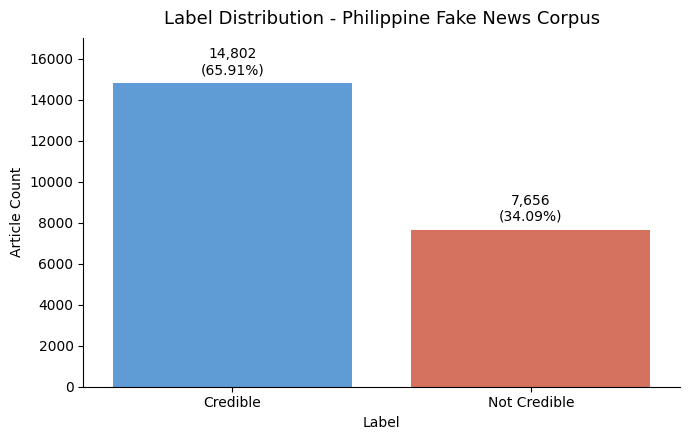

Saved: c:\Users\Lloyd Justin\.jupyter\artifacts\figures\label_distribution.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Robust label distribution summary + plot
label_col = "Label" if "Label" in df.columns else "label"

class_order = ["Credible", "Not Credible"]
label_counts = df[label_col].value_counts().reindex(class_order, fill_value=0)
label_pcts = (label_counts / label_counts.sum() * 100).round(2)

print("Label distribution:")
for label in class_order:
    print(f"  {label:<12} {label_counts[label]:,} articles ({label_pcts[label]}%)")

# Plot
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#4C9BE8", "#E8634C"]

sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    hue=label_counts.index,
    palette=colors,
    dodge=False,
    legend=False,
    ax=ax,
)

ax.set_title("Label Distribution - Philippine Fake News Corpus", fontsize=13, pad=10)
ax.set_xlabel("Label")
ax.set_ylabel("Article Count")

ymax = label_counts.max()
ax.set_ylim(0, ymax * 1.15)
for i, label in enumerate(class_order):
    count = label_counts[label]
    pct = label_pcts[label]
    ax.text(i, count + ymax * 0.02, f"{count:,}\n({pct}%)", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.tight_layout()
label_plot_path = FIGURE_DIR / "label_distribution.png"
plt.savefig(label_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {label_plot_path}")

In [7]:
# Missing values check
missing_per_col = df.isnull().sum()
missing_pct = (missing_per_col / len(df) * 100).round(2)

print("Missing values per column:")
print(missing_per_col)

print("\nMissing percentage per column (%):")
print(missing_pct)

print(f"\nTotal missing: {missing_per_col.sum():,}")

Missing values per column:
Headline       0
Content        0
Authors        0
Date        9141
URL            0
Brand          0
Label          0
dtype: int64

Missing percentage per column (%):
Headline     0.0
Content      0.0
Authors      0.0
Date        40.7
URL          0.0
Brand        0.0
Label        0.0
dtype: float64

Total missing: 9,141


Estimated token counts (Headline + Content combined):
count    22458.0
mean       560.0
std        498.0
min         22.0
50%        424.0
75%        720.0
90%       1102.0
95%       1356.0
99%       2168.0
max      22094.0
Name: est_tokens, dtype: float64

Articles likely exceeding 256 tokens: 16,951 (75.5%)
Articles fitting within 256 tokens:   5,507 (24.5%)


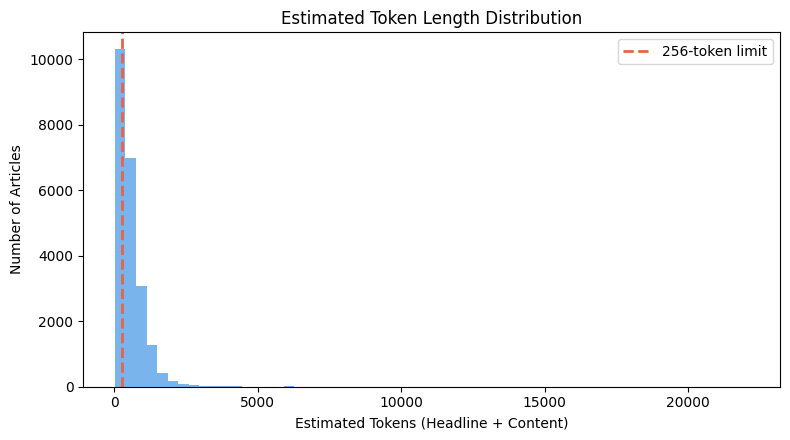

Saved: c:\Users\Lloyd Justin\.jupyter\artifacts\figures\estimated_token_distribution.png


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Text length distribution check for DistilBERT max sequence length (256 tokens)
df["headline_chars"] = df["Headline"].fillna("").astype(str).str.len()
df["content_chars"] = df["Content"].fillna("").astype(str).str.len()
df["combined_chars"] = df["headline_chars"] + df["content_chars"]
df["est_tokens"] = (df["combined_chars"] / 4.5).astype(int)

print("Estimated token counts (Headline + Content combined):")
print(df["est_tokens"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(0))

over_256 = (df["est_tokens"] > 256).sum()
within_256 = len(df) - over_256

print(f"\nArticles likely exceeding 256 tokens: {over_256:,} ({over_256/len(df)*100:.1f}%)")
print(f"Articles fitting within 256 tokens:   {within_256:,} ({within_256/len(df)*100:.1f}%)")

# Distribution plot
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df["est_tokens"], bins=60, color="#4C9BE8", edgecolor=None, ax=ax)
ax.axvline(256, color="#E8634C", linestyle="--", linewidth=2, label="256-token limit")
ax.set_title("Estimated Token Length Distribution")
ax.set_xlabel("Estimated Tokens (Headline + Content)")
ax.set_ylabel("Number of Articles")
ax.legend()
plt.tight_layout()
token_plot_path = FIGURE_DIR / "estimated_token_distribution.png"
plt.savefig(token_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {token_plot_path}")

In [9]:
# Drop only the exact 'date' column (case-insensitive), not other date-like columns
date_cols = [c for c in df.columns if str(c).strip().lower() == "date"]
df = df.drop(columns=date_cols, errors="ignore")
print(f"Dropped date columns: {date_cols if date_cols else 'None'}")
df.head()

Dropped date columns: ['Date']


,Headline,Content,Authors,URL,Brand,Label,headline_chars,content_chars,combined_chars,est_tokens
0,PH ranks 2nd in Asia-Pacific in deaths due to ...,Pollution caused by traditional cooking fuel i...,['Philippine Daily Inquirer'],https://newsinfo.inquirer.net/987262/ph-ranks-...,Inquirer,Credible,65,3267,3332,740
1,"Aguirre, PCSO chief deny plotting to kill ‘Ato...",Justice Secretary Vitaliano Aguirre 2nd and Ph...,['Jomar Canlas'],https://www.manilatimes.net/aguirre-pcso-chief...,Manila Times,Credible,53,3794,3847,854
2,Duterte says charges vs ex-President will fail,President Rodrigo Duterte on Monday night desc...,['Christine O. Avendaño'],https://newsinfo.inquirer.net/914727/duterte-s...,Inquirer,Credible,46,1017,1063,236
3,Group warns BFAR on law enforcement fund,THE militant fisher folk group Pambansang Laka...,['Neil Alcober'],https://www.manilatimes.net/group-warns-bfar-l...,Manila Times,Credible,40,1770,1810,402
4,Solon asks Duterte for jet ski to Panatag,Magdalo Rep. Gary Alejano is willing to lead t...,['Dj Yap'],https://newsinfo.inquirer.net/882744/solon-ask...,Inquirer,Credible,41,2643,2684,596


In [10]:
import re
import pandas as pd

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)  # remove URLs
    text = re.sub(r"<.*?>", " ", text)  # remove HTML tags
    text = re.sub(r"\s+", " ", text).strip()  # collapse whitespace
    return text

In [11]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

# Clean once
df["headline_clean"] = df["Headline"].apply(clean_text)
df["content_clean"] = df["Content"].apply(clean_text)

# Pair encoding:
# - headline is text
# - content is text_pair
# - only_second = keep headline, truncate content first
enc = tokenizer(
    df["headline_clean"].tolist(),
    df["content_clean"].tolist(),
    truncation="only_second",
    max_length=MAX_LENGTH,
    padding=False,
    return_attention_mask=True,
    return_length=True
)

# Store model-ready fields
df["input_ids"] = enc["input_ids"]
df["attention_mask"] = enc["attention_mask"]
df["token_len"] = enc["length"]

df["combined_text"] = df["headline_clean"] + " [SEP] " + df["content_clean"]

# Verify exact limit compliance for configured max length
over_limit = (df["token_len"] > MAX_LENGTH).sum()
within_limit = len(df) - over_limit

print("After tokenizer-based combine:")
print(f"  Within {MAX_LENGTH} tokens: {within_limit:,} ({within_limit/len(df)*100:.1f}%)")
print(f"  Exceeding {MAX_LENGTH}:     {over_limit:,} ({over_limit/len(df)*100:.1f}%)")
print(df["token_len"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

After tokenizer-based combine:
  Within 256 tokens: 22,458 (100.0%)
  Exceeding 256:     0 (0.0%)
count    22458.000000
mean       236.952356
std         41.376285
min         25.000000
50%        256.000000
90%        256.000000
95%        256.000000
99%        256.000000
max        256.000000
Name: token_len, dtype: float64


In [12]:
LABEL_MAP = {"Credible": 0, "Not Credible": 1}

# Normalize source labels first
df["Label_norm"] = df["Label"].astype(str).str.strip().str.title()
df["label"] = df["Label_norm"].map(LABEL_MAP)

unmapped = df["label"].isna().sum()
if unmapped > 0:
    print(f"WARNING: {unmapped} rows could not be mapped")
    print("Unmapped labels:", df.loc[df["label"].isna(), "Label"].unique())
else:
    df["label"] = df["label"].astype(int)
    print("Label encoding successful")

print(f"\n  0 = Credible     -> {(df['label'] == 0).sum():,} articles")
print(f"  1 = Not Credible -> {(df['label'] == 1).sum():,} articles")

Label encoding successful

  0 = Credible     -> 14,802 articles
  1 = Not Credible -> 7,656 articles


In [13]:
APPLY_DEDUP = True  # Set to False to keep duplicates

if APPLY_DEDUP:
    before_rows = len(df)
    df = df.drop_duplicates(subset=["Headline", "Content"], keep="first").reset_index(drop=True)
    removed_rows = before_rows - len(df)
    print(f"Dedup applied: removed {removed_rows:,} duplicate rows (Headline + Content).")
    print(f"Rows before: {before_rows:,} | Rows after: {len(df):,}")
else:
    print("Dedup skipped (APPLY_DEDUP=False).")

Dedup applied: removed 60 duplicate rows (Headline + Content).
Rows before: 22,458 | Rows after: 22,398


#  Tokenization & Train/Val/Test Stratify Split

In [14]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import torch
from transformers import DistilBertTokenizer

processed_dir = PROCESSED_DIR if "PROCESSED_DIR" in globals() else Path("data") / "processed"
checkpoint_dir = CHECKPOINT_DIR if "CHECKPOINT_DIR" in globals() else Path("artifacts") / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Load highest-stage preprocessed CSV (df_XX_*.csv), not newest-by-time
preprocessed_files = sorted(processed_dir.glob("df_*.csv"))
if not preprocessed_files:
    raise FileNotFoundError(
        f"No preprocessed dataset found in {processed_dir} (expected df_*.csv)."
    )


def extract_stage_id(path: Path) -> int:
    match = re.match(r"^df_(\d+)_", path.stem)
    return int(match.group(1)) if match else -1


ranked_files = sorted(
    preprocessed_files,
    key=lambda p: (extract_stage_id(p), p.stat().st_mtime),
    reverse=True,
)
data_path = ranked_files[0]
if extract_stage_id(data_path) < 0:
    raise ValueError(
        f"Unable to parse stage id from selected checkpoint file: {data_path.name}"
    )

df = pd.read_csv(data_path)


def load_weights_file(path: Path):
    """Load class weights with backward compatibility for torch.load signatures."""
    try:
        loaded = torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        loaded = torch.load(path, map_location="cpu")

    if isinstance(loaded, dict) and "class_weights" in loaded:
        loaded = loaded["class_weights"]

    if not isinstance(loaded, torch.Tensor):
        loaded = torch.tensor(loaded, dtype=torch.float32)
    else:
        loaded = loaded.to(dtype=torch.float32, device="cpu")

    return loaded


canonical_weights = checkpoint_dir / "class_weights.pt"
legacy_candidates = [
    canonical_weights,
    Path("checkpoints") / "class_weights.pt",
    Path("class_weights.pt"),
]

weights_path = next((p for p in legacy_candidates if p.exists()), None)
if weights_path is None:
    raise FileNotFoundError(
        "class_weights.pt not found in artifacts/checkpoints, checkpoints, or project root. "
        "Run the class-weights cell first."
    )

# Keep canonical location updated.
if weights_path.resolve() != canonical_weights.resolve():
    canonical_weights.write_bytes(weights_path.read_bytes())
    print(f"INFO: Copied class_weights.pt to canonical path: {canonical_weights}")
    weights_path = canonical_weights

class_weights = load_weights_file(weights_path)

# Validate
assert class_weights.shape == (2,), (
    f"FAIL: class_weights shape {class_weights.shape} - expected (2,)"
)
assert class_weights.dtype == torch.float32, (
    f"FAIL: class_weights dtype {class_weights.dtype} - expected float32"
)

print(f"Loaded data      : {data_path}")
print(f"Loaded weights   : {weights_path}")
print(f"Articles         : {len(df):,}")
print(f"Columns          : {df.columns.tolist()}")
print(f"Credible (0)     : {class_weights[0]:.4f}")
print(f"Not Credible (1) : {class_weights[1]:.4f}")

Loaded data      : c:\Users\Lloyd Justin\.jupyter\data\processed\df_03_length_features.csv
Loaded weights   : c:\Users\Lloyd Justin\.jupyter\artifacts\checkpoints\class_weights.pt
Articles         : 22,458
Columns          : ['Headline', 'Content', 'Authors', 'Date', 'URL', 'Brand', 'Label', 'headline_chars', 'content_chars', 'combined_chars', 'est_tokens']
Credible (0)     : 0.7566
Not Credible (1) : 1.4742


In [15]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Build combined text if not already present (no tokenization here)
if "combined_text" not in df.columns:
    df["combined_text"] = (
        df["Headline"].fillna("").astype(str).str.strip()
        + " [SEP] "
        + df["Content"].fillna("").astype(str).str.strip()
    )

# Ensure numeric binary label exists for stratification
if "label" not in df.columns or not pd.api.types.is_integer_dtype(df["label"]):
    label_map = {"Credible": 0, "Not Credible": 1}
    df["label"] = (
        df["Label"].astype(str).str.strip().str.title().map(label_map)
    )

if df["label"].isna().any():
    bad = sorted(df.loc[df["label"].isna(), "Label"].astype(str).unique().tolist())
    raise ValueError(f"Unmapped labels found: {bad}")

df["label"] = df["label"].astype(int)

# Strict dedup before any sampling/splitting to prevent leakage across splits
# Keep one row per exact text+label; fail-fast if same text has conflicting labels.
conflicts = df.groupby("combined_text", dropna=False)["label"].nunique()
conflict_count = int((conflicts > 1).sum())
if conflict_count > 0:
    raise ValueError(
        f"Found {conflict_count} conflicting text entries with different labels. "
        "Resolve conflicts before splitting."
    )

before_dedup = len(df)
df = df.drop_duplicates(subset=["combined_text", "label"], keep="first").reset_index(drop=True)
removed_dedup = before_dedup - len(df)
print(f"Dedup before split: removed {removed_dedup:,} duplicate text rows.")

# Keep the full dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nUsing full dataset:")
print(f"  Credible     : {(df['label'] == 0).sum():,}")
print(f"  Not Credible : {(df['label'] == 1).sum():,}")
print(f"  Total        : {len(df):,}")

X = df["combined_text"].values
y = df["label"].values

# Safety: each class must have enough examples for stratified splitting
class_counts = pd.Series(y).value_counts().sort_index()
if (class_counts < 2).any():
    raise ValueError(f"Not enough samples per class for stratified split: {class_counts.to_dict()}")

# Step 1 - carve out test set permanently
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

# Step 2 - split remainder into train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1111111111,  # 0.1111111111 of 90% = 10% of total
    random_state=42,
    stratify=y_temp
)

# Verify no overlap across splits (strict leakage guard)
train_set = set(map(str, X_train))
val_set = set(map(str, X_val))
test_set = set(map(str, X_test))

assert len(train_set & test_set) == 0, "Leakage detected: train-test overlap"
assert len(val_set & test_set) == 0, "Leakage detected: val-test overlap"
assert len(train_set & val_set) == 0, "Leakage detected: train-val overlap"

# Verify total consistency
total = len(X_train) + len(X_val) + len(X_test)
assert total == len(df), f"Split size mismatch: {total} != {len(df)}"

print("Split sizes:")
print(f"  Train : {len(X_train):,} articles ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Val   : {len(X_val):,} articles ({len(X_val)/len(df)*100:.1f}%)")
print(f"  Test  : {len(X_test):,} articles ({len(X_test)/len(df)*100:.1f}%)")
print(f"  Total : {total:,}")

# Verify stratification held
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    cred = (y_split == 0).sum()
    fake = (y_split == 1).sum()
    print(f"\n  {name} distribution:")
    print(f"    Credible     : {cred:,} ({cred/len(y_split)*100:.1f}%)")
    print(f"    Not Credible : {fake:,} ({fake/len(y_split)*100:.1f}%)")

Dedup before split: removed 60 duplicate text rows.

Using full dataset:
  Credible     : 14,802
  Not Credible : 7,596
  Total        : 22,398
Split sizes:
  Train : 17,918 articles (80.0%)
  Val   : 2,240 articles (10.0%)
  Test  : 2,240 articles (10.0%)
  Total : 22,398

  Train distribution:
    Credible     : 11,842 (66.1%)
    Not Credible : 6,076 (33.9%)

  Val distribution:
    Credible     : 1,480 (66.1%)
    Not Credible : 760 (33.9%)

  Test distribution:
    Credible     : 1,480 (66.1%)
    Not Credible : 760 (33.9%)


In [16]:
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights from TRAIN labels only
classes = np.array([0, 1])
present_classes = np.unique(y_train)
missing_classes = set(classes.tolist()) - set(present_classes.tolist())
if missing_classes:
    raise ValueError(f"Cannot compute full binary class weights. Missing class(es) in y_train: {sorted(missing_classes)}")

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train  # training set only
)

class_weights = torch.tensor(weights, dtype=torch.float32)

print("Class weights (from y_train only):")
print(f"  Credible (0)     : {weights[0]:.4f}")
print(f"  Not Credible (1) : {weights[1]:.4f}")
print(f"\nPenalizes missing a fake article ~{weights[1]/weights[0]:.1f}x more than a real one")

Class weights (from y_train only):
  Credible (0)     : 0.7565
  Not Credible (1) : 1.4745

Penalizes missing a fake article ~1.9x more than a real one


In [17]:
from transformers import DistilBertTokenizer

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size : {tokenizer.vocab_size:,}")
print(f"Max length : {MAX_LENGTH}")

Tokenizer loaded: distilbert-base-uncased
Vocab size : 30,522
Max length : 256


In [18]:
def tokenize_split(texts, tokenizer, max_length=MAX_LENGTH):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

# Safety checks
if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
    raise ValueError("One or more splits are empty. Run the split cell first.")

print("Tokenizing train set")
train_encodings = tokenize_split(X_train, tokenizer, max_length=MAX_LENGTH)
print(f"  Done - input_ids shape: {tuple(train_encodings['input_ids'].shape)}")

print("Tokenizing val set")
val_encodings = tokenize_split(X_val, tokenizer, max_length=MAX_LENGTH)
print(f"  Done - input_ids shape: {tuple(val_encodings['input_ids'].shape)}")

print("Tokenizing test set")
test_encodings = tokenize_split(X_test, tokenizer, max_length=MAX_LENGTH)
print(f"  Done - input_ids shape: {tuple(test_encodings['input_ids'].shape)}")

print("\nAll splits tokenized successfully")

Tokenizing train set
  Done - input_ids shape: (17918, 256)
Tokenizing val set
  Done - input_ids shape: (2240, 256)
Tokenizing test set
  Done - input_ids shape: (2240, 256)

All splits tokenized successfully


In [19]:
from torch.utils.data import Dataset, DataLoader
import torch

class PhilNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.input_ids = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels = torch.tensor(labels, dtype=torch.long)

        if len(self.input_ids) != len(self.labels):
            raise ValueError(
                f"Length mismatch: input_ids={len(self.input_ids)} vs labels={len(self.labels)}"
            )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label": self.labels[idx],
        }

# Build datasets
train_dataset = PhilNewsDataset(train_encodings, y_train)
val_dataset = PhilNewsDataset(val_encodings, y_val)
test_dataset = PhilNewsDataset(test_encodings, y_test)

# Build dataloaders
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Datasets ready:")
print(f"  Train   : {len(train_dataset):,} samples -> {len(train_loader)} batches")
print(f"  Val     : {len(val_dataset):,} samples -> {len(val_loader)} batches")
print(f"  Test    : {len(test_dataset):,} samples -> {len(test_loader)} batches")
print(f"  Batch size : {BATCH_SIZE}")

Datasets ready:
  Train   : 17,918 samples -> 1120 batches
  Val     : 2,240 samples -> 140 batches
  Test    : 2,240 samples -> 140 batches
  Batch size : 16


In [20]:
from pathlib import Path
import torch

checkpoint_dir = CHECKPOINT_DIR if "CHECKPOINT_DIR" in globals() else Path("artifacts") / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
cell24_path = checkpoint_dir / "cell24_checkpoint.pt"

torch.save(
    {
        "train_encodings": train_encodings,
        "val_encodings": val_encodings,
        "test_encodings": test_encodings,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "class_weights": class_weights,
    },
    cell24_path,
)

print(f"Checkpoint saved -> {cell24_path}")
print("\nQuick summary:")
print(f"  Tokenizer  : {MODEL_NAME}")
print(f"  Max tokens : {MAX_LENGTH}")
print(f"  Train      : {len(train_dataset):,} samples")
print(f"  Val        : {len(val_dataset):,} samples")
print(f"  Test       : {len(test_dataset):,} samples")
print(f"  Weights    : Credible={weights[0]:.4f} · Not Credible={weights[1]:.4f}")

Checkpoint saved -> c:\Users\Lloyd Justin\.jupyter\artifacts\checkpoints\cell24_checkpoint.pt

Quick summary:
  Tokenizer  : distilbert-base-uncased
  Max tokens : 256
  Train      : 17,918 samples
  Val        : 2,240 samples
  Test       : 2,240 samples
  Weights    : Credible=0.7565 · Not Credible=1.4745


# Building DistilBERT Model

In [21]:
import torch.nn as nn

class DistilBertClassifier(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout=DROPOUT, num_labels=2):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(p=dropout)
        self.classifier = nn.Linear(self.distilbert.config.hidden_size, num_labels)

        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask=None, return_features=False):
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)

        cls_output = outputs.last_hidden_state[:, 0, :]
        dropped = self.dropout(cls_output)
        logits = self.classifier(dropped)

        if return_features:
            return logits, cls_output
        return logits

In [22]:
device = DEVICE if "DEVICE" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertClassifier(dropout=0.4)
model.to(device)
print("✓ Model instantiated and moved to:", device)
print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model instantiated and moved to: cpu
DistilBertClassifier(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropou

In [23]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Compute weights from y_train only (no leakage).
classes = np.array([0, 1])
present = np.unique(y_train)
missing = set(classes.tolist()) - set(present.tolist())
if missing:
    raise ValueError(f"Missing class(es) in y_train: {sorted(missing)}")

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print(f"Credible (0) weight    : {weights[0]:.4f}")
print(f"Not Credible (1) weight: {weights[1]:.4f}")

# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Loss function ready")

Credible (0) weight    : 0.7565
Not Credible (1) weight: 1.4745
Loss function ready


In [24]:
model.eval()
with torch.no_grad():
    sample_ids  = train_encodings["input_ids"][:2].to(device)
    sample_mask = train_encodings["attention_mask"][:2].to(device)
    output      = model(sample_ids, sample_mask)
    print(f"Output shape : {output.shape}")   # expect torch.Size([2, 2])
    print(f"Sample logits: {output}")

Output shape : torch.Size([2, 2])
Sample logits: tensor([[-0.0040, -1.1283],
        [-0.1333, -1.1185]])


# Training DistilBERT Model

In [25]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

EPOCHS = 5
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10

steps_per_epoch = len(train_loader)
total_steps = max(1, steps_per_epoch * EPOCHS)
warmup_steps = int(WARMUP_RATIO * total_steps)
warmup_steps = min(warmup_steps, total_steps - 1) if total_steps > 1 else 0

if getattr(train_loader, "batch_size", None) != BATCH_SIZE:
    print(
        f"Note: train_loader batch_size={train_loader.batch_size} "
        f"but configured BATCH_SIZE={BATCH_SIZE}."
    )

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Epochs               : {EPOCHS}")
print(f"Batch size           : {BATCH_SIZE}")
print(f"Steps / epoch        : {steps_per_epoch}")
print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps} ({WARMUP_RATIO:.0%})")
print(f"Optimizer            : AdamW | lr={LEARNING_RATE} | weight_decay={WEIGHT_DECAY}")
print("Scheduler            : Linear warmup + decay")

Epochs               : 5
Batch size           : 16
Steps / epoch        : 1120
Total training steps : 5600
Warmup steps         : 560 (10%)
Optimizer            : AdamW | lr=2e-05 | weight_decay=0.01
Scheduler            : Linear warmup + decay


In [26]:
def train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total_samples = 0

    num_batches = len(train_loader)
    if num_batches == 0:
        raise ValueError("train_loader is empty. Cannot run training.")

    for batch_idx, batch in enumerate(train_loader, start=1):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)

        labels = batch.get("labels")
        if labels is None:
            labels = batch.get("label")
        if labels is None:
            raise KeyError("Batch is missing both 'labels' and 'label' keys.")
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        if batch_idx % 100 == 0 or batch_idx == num_batches:
            print(f"  Batch {batch_idx}/{num_batches} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / num_batches
    accuracy = correct / total_samples if total_samples > 0 else 0.0
    return avg_loss, accuracy

In [27]:
def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total_samples = 0

    num_batches = len(val_loader)
    if num_batches == 0:
        raise ValueError("val_loader is empty. Cannot run evaluation.")

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)

            labels = batch.get("labels")
            if labels is None:
                labels = batch.get("label")
            if labels is None:
                raise KeyError("Batch is missing both 'labels' and 'label' keys.")
            labels = labels.to(device, non_blocking=True)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / num_batches
    accuracy = correct / total_samples if total_samples > 0 else 0.0
    return avg_loss, accuracy

In [28]:
import math
import random
import time
from pathlib import Path

import numpy as np
import torch

# Tracking
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Early stopping config
best_val_loss = float("inf")
patience = 3
patience_count = 0
best_epoch = 0
min_delta = 1e-6

if EPOCHS <= 0:
    raise ValueError("EPOCHS must be greater than 0.")

save_path = Path(globals().get("MODEL_SAVE_PATH", Path("artifacts") / "models" / "best_model.pt"))
save_path.parent.mkdir(parents=True, exist_ok=True)
checkpoint_path = Path(globals().get("FULL_CHECKPOINT_PATH", Path("artifacts") / "checkpoints" / "full_checkpoint.pt"))
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
resume_if_available = True


def save_full_checkpoint(epoch, is_best=False):
    checkpoint = {
        "epoch": epoch,
        "best_epoch": best_epoch,
        "patience_count": patience_count,
        "model_state": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict() if scheduler is not None else None,
        "best_val_loss": best_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "model_save_path": str(save_path),
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "python_random_state": random.getstate(),
        "numpy_random_state": np.random.get_state(),
        "torch_random_state": torch.get_rng_state(),
        "cuda_random_state_all": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }

    tmp_path = checkpoint_path.with_suffix(".tmp")
    torch.save(checkpoint, tmp_path)
    tmp_path.replace(checkpoint_path)

    suffix = " (best)" if is_best else ""
    print(f"  Full checkpoint saved{suffix} -> {checkpoint_path}")


start_epoch = 1
if resume_if_available and checkpoint_path.exists():
    try:
        loaded = torch.load(checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        # Backward compatibility for torch versions without weights_only argument.
        loaded = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(loaded["model_state"])
    optimizer.load_state_dict(loaded["optimizer"])
    if scheduler is not None and loaded.get("scheduler") is not None:
        scheduler.load_state_dict(loaded["scheduler"])

    best_val_loss = float(loaded.get("best_val_loss", best_val_loss))
    best_epoch = int(loaded.get("best_epoch", best_epoch))
    patience_count = int(loaded.get("patience_count", 0))

    train_losses = list(loaded.get("train_losses", []))
    val_losses = list(loaded.get("val_losses", []))
    train_accs = list(loaded.get("train_accs", []))
    val_accs = list(loaded.get("val_accs", []))

    if "python_random_state" in loaded:
        random.setstate(loaded["python_random_state"])
    if "numpy_random_state" in loaded:
        np.random.set_state(loaded["numpy_random_state"])
    if "torch_random_state" in loaded:
        torch.set_rng_state(loaded["torch_random_state"])
    if torch.cuda.is_available() and loaded.get("cuda_random_state_all") is not None:
        torch.cuda.set_rng_state_all(loaded["cuda_random_state_all"])

    start_epoch = int(loaded.get("epoch", 0)) + 1

    print("Resuming from full checkpoint")
    print(f"  Last completed epoch : {start_epoch - 1}")
    print(f"  Best epoch so far    : {best_epoch}")
    print(f"  Best val loss so far : {best_val_loss:.4f}")
elif resume_if_available:
    print(f"No existing full checkpoint found at: {checkpoint_path}")
    print("Starting a fresh training run and creating a new full checkpoint.")
elif checkpoint_path.exists():
    print(f"Existing {checkpoint_path.name} found, but resume_if_available=False.")
    print("Starting a fresh training run for the current dataset setup.")

print("Starting training...")
print("=" * 55)

interrupted = False
failed = False

if start_epoch > EPOCHS:
    print(f"Checkpoint already reached epoch {start_epoch - 1}, target is EPOCHS={EPOCHS}.")
else:
    for epoch in range(start_epoch, EPOCHS + 1):
        try:
            start = time.perf_counter()
            print(f"\nEpoch {epoch}/{EPOCHS}")
            print("-" * 55)

            # Train
            train_loss, train_acc = train_one_epoch(
                model, train_loader, optimizer, scheduler, criterion, device
            )

            # Validate
            val_loss, val_acc = evaluate(model, val_loader, criterion, device)

            # Guard against unstable training signals
            if not (math.isfinite(train_loss) and math.isfinite(val_loss)):
                raise ValueError(
                    f"Non-finite loss detected (train={train_loss}, val={val_loss})."
                )

            # Track history
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            elapsed = time.perf_counter() - start
            print(f"\n  Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f}")
            print(f"  Val Loss   : {val_loss:.4f}   | Val Acc   : {val_acc:.4f}")
            print(f"  Time       : {elapsed / 60:.1f} min")

            # Early stopping check
            is_best = False
            if val_loss < (best_val_loss - min_delta):
                best_val_loss = val_loss
                best_epoch = epoch
                patience_count = 0
                torch.save(model.state_dict(), save_path)
                is_best = True
                print(f"  Best model saved (val_loss={best_val_loss:.4f}) -> {save_path}")
            else:
                patience_count += 1
                print(f"  No improvement | patience {patience_count}/{patience}")

            # Save a full checkpoint every epoch so progress is never lost.
            save_full_checkpoint(epoch=epoch, is_best=is_best)

            if patience_count >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch}")
                break

        except KeyboardInterrupt:
            interrupted = True
            print("\nTraining interrupted. Saving last complete checkpoint...")
            completed_epochs = len(train_losses)
            if completed_epochs > 0:
                save_full_checkpoint(epoch=completed_epochs, is_best=False)
            break

        except Exception:
            failed = True
            completed_epochs = len(train_losses)
            print("\nTraining error encountered. Saving last complete checkpoint before raising...")
            if completed_epochs > 0:
                save_full_checkpoint(epoch=completed_epochs, is_best=False)
            raise

print("\n" + "=" * 55)
if failed:
    print("Training stopped due to error.")
elif interrupted:
    print("Training stopped early (interrupted).")
else:
    print("Training complete!")
print(f"   Best epoch       : {best_epoch}")
print(f"   Best val loss    : {best_val_loss:.4f}")
print(f"   Saved weights    : {save_path}")
print(f"   Full checkpoint  : {checkpoint_path}")
print("=" * 55)

Resuming from full checkpoint
  Last completed epoch : 5
  Best epoch so far    : 2
  Best val loss so far : 0.0874
Starting training...
Checkpoint already reached epoch 5, target is EPOCHS=5.

Training complete!
   Best epoch       : 2
   Best val loss    : 0.0874
   Saved weights    : c:\Users\Lloyd Justin\.jupyter\artifacts\models\distilbert_ph_fakenews.pth
   Full checkpoint  : c:\Users\Lloyd Justin\.jupyter\artifacts\checkpoints\full_checkpoint.pt


Best model reloaded from: c:\Users\Lloyd Justin\.jupyter\artifacts\models\distilbert_ph_fakenews.pth (epoch 2)


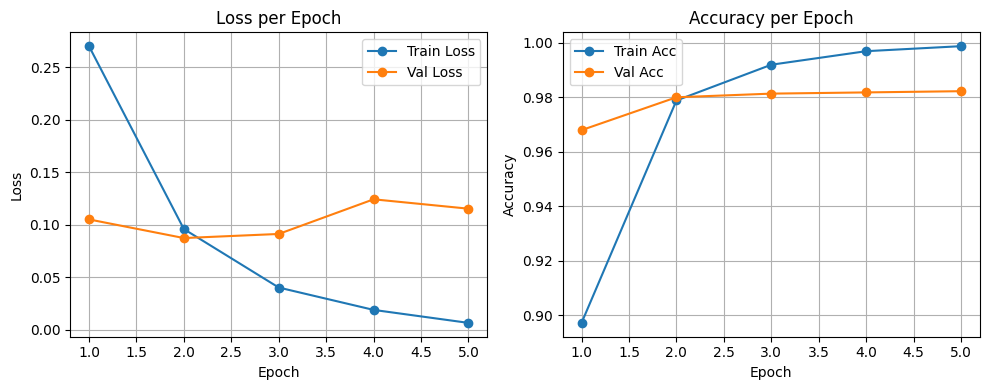

Training curves saved to c:\Users\Lloyd Justin\.jupyter\artifacts\figures\training_curves.png

Training Summary
  Epoch 1 | Train Loss: 0.2701 | Val Loss: 0.1051 | Train Acc: 0.8971 | Val Acc: 0.9679
  Epoch 2 | Train Loss: 0.0960 | Val Loss: 0.0874 | Train Acc: 0.9787 | Val Acc: 0.9799 <- best
  Epoch 3 | Train Loss: 0.0403 | Val Loss: 0.0913 | Train Acc: 0.9919 | Val Acc: 0.9812
  Epoch 4 | Train Loss: 0.0190 | Val Loss: 0.1243 | Train Acc: 0.9968 | Val Acc: 0.9817
  Epoch 5 | Train Loss: 0.0066 | Val Loss: 0.1154 | Train Acc: 0.9987 | Val Acc: 0.9821


In [29]:
import matplotlib.pyplot as plt
import torch
from pathlib import Path

# ── 1. Reload best model weights ─────────────────────────────
candidate_paths = []
if "save_path" in globals():
    candidate_paths.append(Path(str(save_path)))
if "MODEL_SAVE_PATH" in globals():
    candidate_paths.append(Path(MODEL_SAVE_PATH))
candidate_paths.append(Path("artifacts") / "models" / "distilbert_ph_fakenews.pth")
candidate_paths.append(Path("best_model.pt"))

seen = set()
existing_paths = []
for p in candidate_paths:
    rp = p.resolve()
    if str(rp) in seen:
        continue
    seen.add(str(rp))
    if p.exists():
        existing_paths.append(p)

if not existing_paths:
    raise FileNotFoundError(
        "No model weights file found. Expected one of: "
        + ", ".join(str(p) for p in candidate_paths)
    )

weights_path = existing_paths[0]
model.load_state_dict(torch.load(weights_path, map_location=device))
print(f"Best model reloaded from: {weights_path} (epoch {best_epoch})")

# ── 2. Plot loss curve ────────────────────────────────────────
epochs_ran = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_losses, marker="o", label="Train Loss")
plt.plot(epochs_ran, val_losses, marker="o", label="Val Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, train_accs, marker="o", label="Train Acc")
plt.plot(epochs_ran, val_accs, marker="o", label="Val Acc")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
figure_dir = FIGURE_DIR if "FIGURE_DIR" in globals() else Path("artifacts") / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
training_curve_path = figure_dir / "training_curves.png"
plt.savefig(training_curve_path, dpi=150)
plt.show()
print(f"Training curves saved to {training_curve_path}")

# ── 3. Final summary ─────────────────────────────────────────
print("\nTraining Summary")
for i, (tl, vl, ta, va) in enumerate(zip(train_losses, val_losses, train_accs, val_accs)):
    marker = " <- best" if (i + 1) == best_epoch else ""
    print(
        f"  Epoch {i + 1} | "
        f"Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | "
        f"Train Acc: {ta:.4f} | Val Acc: {va:.4f}{marker}"
    )

# Evaluation Report

In [30]:
import numpy as np

model.eval()

pred_chunks = []
label_chunks = []
prob_chunks = []

with torch.inference_mode():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels_key = "labels" if "labels" in batch else "label"
        labels = batch[labels_key].to(device)

        logits = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=-1)
        preds = torch.argmax(logits, dim=-1)

        pred_chunks.append(preds.cpu())
        label_chunks.append(labels.cpu())
        prob_chunks.append(probs.cpu())

if pred_chunks:
    all_preds = torch.cat(pred_chunks).numpy()
    all_labels = torch.cat(label_chunks).numpy()
    all_probs = torch.cat(prob_chunks).numpy()
else:
    all_preds = np.array([], dtype=np.int64)
    all_labels = np.array([], dtype=np.int64)
    all_probs = np.empty((0, 0), dtype=np.float32)

print(f"Predictions done on {len(all_preds):,} test samples")

Predictions done on 2,240 test samples


In [31]:
from sklearn.metrics import classification_report

test_acc = float((all_preds == all_labels).mean())
val_acc_ref = 0.94

print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Val  Accuracy : {val_acc_ref:.4f} ({val_acc_ref*100:.2f}%)  <- from training")
print(f"Difference    : {abs(test_acc - val_acc_ref)*100:.2f}%")
print()
print(classification_report(
    all_labels,
    all_preds,
    labels=[0, 1],
    target_names=["Credible", "Not Credible"],
    digits=4,
    zero_division=0,
))

Test Accuracy : 0.9781 (97.81%)
Val  Accuracy : 0.9400 (94.00%)  <- from training
Difference    : 3.81%

              precision    recall  f1-score   support

    Credible     0.9805    0.9865    0.9835      1480
Not Credible     0.9734    0.9618    0.9676       760

    accuracy                         0.9781      2240
   macro avg     0.9769    0.9742    0.9755      2240
weighted avg     0.9781    0.9781    0.9781      2240



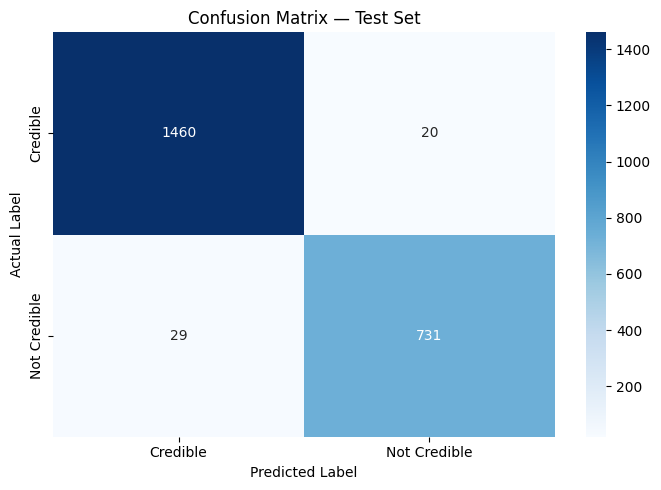


True Negatives  (Credible -> Credible)        : 1460
False Positives (Credible -> Not Credible)    : 20
False Negatives (Not Credible -> Credible)    : 29
True Positives  (Not Credible -> Not Credible): 731


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Credible", "Not Credible"],
    yticklabels=["Credible", "Not Credible"],
)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Break it down
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Credible -> Credible)        : {tn}")
print(f"False Positives (Credible -> Not Credible)    : {fp}")
print(f"False Negatives (Not Credible -> Credible)    : {fn}")
print(f"True Positives  (Not Credible -> Not Credible): {tp}")

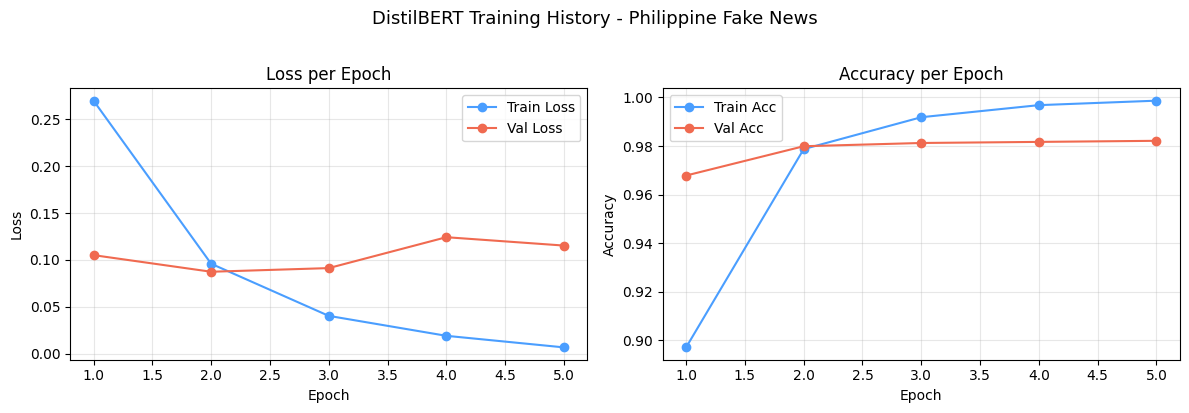

Training curves saved to training_curves.png


In [33]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(epochs_ran, train_losses, marker="o", label="Train Loss", color="#4a9eff")
axes[0].plot(epochs_ran, val_losses, marker="o", label="Val Loss", color="#f06a50")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_ran, train_accs, marker="o", label="Train Acc", color="#4a9eff")
axes[1].plot(epochs_ran, val_accs, marker="o", label="Val Acc", color="#f06a50")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("DistilBERT Training History - Philippine Fake News", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved to training_curves.png")

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Use same train/test text splits
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

models = {
    "TF-IDF + Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "TF-IDF + Naive Bayes": MultinomialNB(),
    "TF-IDF + Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "TF-IDF + SVM": LinearSVC(random_state=42),
}

model_accuracies = {}
model_predictions = {}

for model_name, clf in models.items():
    clf.fit(X_train_tfidf, y_train)
    preds = clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)

    model_accuracies[model_name] = acc
    model_predictions[model_name] = preds

    print(f"-- Baseline: {model_name} ----------------")
    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print()
    print(classification_report(
        y_test,
        preds,
        labels=[0, 1],
        target_names=["Credible", "Not Credible"],
        digits=4,
        zero_division=0,
    ))

# Keep prior variable names for compatibility with later cells
lr_model = models["TF-IDF + Logistic Regression"]
lr_preds = model_predictions["TF-IDF + Logistic Regression"]
lr_accuracy = model_accuracies["TF-IDF + Logistic Regression"]

print("-- Model Comparison -----------------------------")
for name, acc in sorted(model_accuracies.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<28}: {acc*100:.2f}%")
print(f"  DistilBERT{'':<19}: {test_acc*100:.2f}%")

-- Baseline: TF-IDF + Logistic Regression ----------------
Accuracy : 0.9580 (95.80%)

              precision    recall  f1-score   support

    Credible     0.9614    0.9757    0.9685      1480
Not Credible     0.9512    0.9237    0.9372       760

    accuracy                         0.9580      2240
   macro avg     0.9563    0.9497    0.9529      2240
weighted avg     0.9579    0.9580    0.9579      2240

-- Baseline: TF-IDF + Naive Bayes ----------------
Accuracy : 0.9161 (91.61%)

              precision    recall  f1-score   support

    Credible     0.9359    0.9372    0.9365      1480
Not Credible     0.8773    0.8750    0.8762       760

    accuracy                         0.9161      2240
   macro avg     0.9066    0.9061    0.9063      2240
weighted avg     0.9160    0.9161    0.9160      2240

-- Baseline: TF-IDF + Random Forest ----------------
Accuracy : 0.9455 (94.55%)

              precision    recall  f1-score   support

    Credible     0.9491    0.9696    0.9592 

# Tesseract OCR Implementation

In [35]:
import pytesseract
from PIL import Image
import os

# Provide a fallback path for Linux/Other Windows users
if os.name == 'nt':
    tesseract_path = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
    if os.path.exists(tesseract_path):
        pytesseract.pytesseract.tesseract_cmd = tesseract_path

# Verify
try:
    print(f"Tesseract version : {pytesseract.get_tesseract_version()}")
    print("Tesseract ready!")
except Exception as e:
    print("Tesseract not found or properly configured for this OS.")
    print(e)

Tesseract version : 5.5.0.20241111
Tesseract ready!


In [36]:
import re
import unicodedata

import pytesseract
from PIL import Image

_URL_RE = re.compile(r"\b(?:https?://|www\.)\S+\b", re.IGNORECASE)
_HTML_RE = re.compile(r"<[^>]+>")
_ALLOWED_RE = re.compile(r"[^a-zA-Z0-9\s.,!?;:'\"-]")
_SPACE_RE = re.compile(r"\s+")
_REPEAT_PUNCT_RE = re.compile(r"([.!?])\1{2,}")
_OCR_NORMALIZE = str.maketrans({
    "@": "o",
    "0": "o",
    "1": "l",
    "|": "l",
})


def clean_ocr_text(text: str) -> str:
    """Clean raw Tesseract output for DistilBERT input."""
    if text is None:
        return ""
    if not isinstance(text, str):
        text = str(text)

    text = text.replace("\x0c", " ")
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", errors="ignore").decode("ascii")

    text = _URL_RE.sub(" ", text)
    text = _HTML_RE.sub(" ", text)
    text = text.translate(_OCR_NORMALIZE)
    text = _ALLOWED_RE.sub(" ", text)
    text = _REPEAT_PUNCT_RE.sub(r"\1\1", text)
    text = _SPACE_RE.sub(" ", text).strip()

    return text.lower()


def ocr_image_to_clean_text(image_path, lang="eng", config="--oem 3 --psm 6"):
    """Run Tesseract on an image path and return cleaned text."""
    with Image.open(image_path) as img:
        raw = pytesseract.image_to_string(img, lang=lang, config=config)
    return clean_ocr_text(raw)


# Quick test
sample = "He11o W@rld!! Visit http://fake.com for m0re!!!"
print(f"Before: {sample}")
print(f"After : {clean_ocr_text(sample)}")
print("OCR cleaner ready!")

Before: He11o W@rld!! Visit http://fake.com for m0re!!!
After : hello world!! visit for more!!
OCR cleaner ready!


In [37]:
def predict_text(text, max_chunks=5):
    """
    Predict credibility of a single text input using a chunking strategy.
    Splits long text into smaller chunks, predicts on each, and averages the results.
    """
    if not text or str(text).strip() == "":
        return {
            "prediction" : "UNKNOWN",
            "confidence" : 0.0,
            "reason"     : "Empty text",
            "input"      : ""
        }

    cleaned = clean_text(text)
    
    # Tokenize the entire text without truncating to get all tokens
    # (We disable add_special_tokens here so we can add them manually per chunk)
    tokens = tokenizer(cleaned, add_special_tokens=False, return_tensors="pt")
    input_ids_full = tokens["input_ids"][0]
    
    # Calculate chunk size (MAX_LENGTH - 2 to leave room for [CLS] and [SEP])
    chunk_size = MAX_LENGTH - 2
    
    # Split the tokens into chunks
    chunks = [input_ids_full[i:i+chunk_size] for i in range(0, len(input_ids_full), chunk_size)]
    
    # Limit number of chunks to prevent memory/time issues on extremely long trash text
    chunks = chunks[:max_chunks]
    
    all_probs = []
    
    model.eval()
    with torch.no_grad():
        for chunk in chunks:
            # Manually add [CLS] and [SEP] tokens to each chunk
            chunk_ids = torch.cat([
                torch.tensor([tokenizer.cls_token_id]), 
                chunk, 
                torch.tensor([tokenizer.sep_token_id])
            ]).unsqueeze(0).to(device)
            
            chunk_mask = torch.ones_like(chunk_ids).to(device)
            
            # Predict for this chunk
            logits = model(chunk_ids, chunk_mask)
            probs = torch.softmax(logits, dim=1)
            all_probs.append(probs)
    
    # Average the probabilities across all chunks
    avg_probs = torch.mean(torch.cat(all_probs, dim=0), dim=0)
    pred_class = torch.argmax(avg_probs).item()
    confidence = avg_probs[pred_class].item()

    label = "CREDIBLE" if pred_class == 0 else "NOT CREDIBLE"

    return {
        "input"      : cleaned[:80] + ("..." if len(cleaned) > 80 else ""),
        "prediction" : label,
        "confidence" : round(confidence * 100, 2),
        "class_id"   : pred_class,
        "chunks_used": len(chunks)
    }

def predict_image(image_path, ocr_lang="eng", ocr_config="--oem 3 --psm 6"):
    """Predict credibility from a news screenshot."""

    # OCR: Use context manager to prevent file-locking issues, add OCR configs
    with Image.open(image_path) as image:
        raw_text = pytesseract.image_to_string(image, lang=ocr_lang, config=ocr_config)

    print(f"── OCR Raw Output ───────────────────────────")
    print(raw_text[:300] + ("..." if len(raw_text) > 300 else ""))
    print(f"────────────────────────────────────────────")

    # Predict using extracted text
    result = predict_text(raw_text)
    result["image_path"] = image_path
    result["ocr_length"] = len(raw_text.split())

    return result

def display_result(result):
    """Pretty print prediction result."""
    print(f"\n{'='*50}")
    print(f"  {result['prediction']}")
    print(f"{'='*50}")
    print(f"  Confidence : {result['confidence']}%")
    if "chunks_used" in result:
        print(f"  Chunks Avg : {result['chunks_used']}")
    if "image_path" in result:
        print(f"  Image      : {result['image_path']}")
        print(f"  OCR words  : {result.get('ocr_length', 0)}")
    if "reason" in result:
        print(f"  Reason     : {result['reason']}")
    print(f"  Input      : {result['input']}")
    print(f"{'='*50}\n")

print("predict_text() ready")
print("predict_image() ready")
print("display_result() ready")

predict_text() ready
predict_image() ready
display_result() ready


In [38]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Using pathlib for consistent path handling
SCREENSHOT_FOLDER = Path("news_screenshots")
SCREENSHOT_FOLDER.mkdir(exist_ok=True)

# Supported formats
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

# Get all images in folder
image_files = [
    f for f in SCREENSHOT_FOLDER.iterdir()
    if f.is_file() and f.suffix.lower() in image_extensions
]

if not image_files:
    print(f"No images found in '{SCREENSHOT_FOLDER.resolve()}'")
    print(f"   Add some news screenshots there and rerun the cell.")
else:
    print(f"Found {len(image_files)} screenshot(s) to analyze\n")
    results = []

    for img_path in image_files:
        print(f"Processing: {img_path.name}")
        try:
            # Predict
            result = predict_image(str(img_path))
            display_result(result)
            results.append(result)
        except Exception as e:
            print(f"Failed to process {img_path.name}: {e}")

    # Summary table
    if results:
        print("\n── Summary ──────────────────────────────────")
        print(f"{'Image':<30} {'Prediction':<15} {'Confidence (%)'}")
        print("-" * 55)
        for r in results:
            img_name = Path(r['image_path']).name[:28]
            conf = r.get('confidence', 0.0)
            pred = r.get('prediction', 'UNKNOWN')
            print(f"{img_name:<30} {pred:<15} {conf:>6.2f}")

Found 7 screenshot(s) to analyze

Processing: 682614212_970998328880796_1229433786145186305_n.jpg
── OCR Raw Output ───────────────────────────
~~ i Se.)
v i Se rh.
wy
| —_ y) ; =
Davao City Signs Historic
Railway.Contract
Davao City mayor Baste Duterte and the
Japanese Governor of Gensokyo, Yukari
Yakumo, sign a contract for the feasibility
study for the historic Davao City subway

────────────────────────────────────────────

  NOT CREDIBLE
  Confidence : 95.15%
  Chunks Avg : 1
  Image      : news_screenshots\682614212_970998328880796_1229433786145186305_n.jpg
  OCR words  : 44
  Input      : ~~ i se.) v i se rh. wy | —_ y) ; = davao city signs historic railway.contract d...

Processing: 683806412_1324318826261179_7499100413550817994_n.jpg
── OCR Raw Output ───────────────────────────
tiibune BREAKING news
bia MINDANAO Sunday, May 3, 2026
COURT ALLOWS JAY SONZA
TO POST BAIL, SAYS LAWYER
The Pasay City Regional | *
Trial Court Branch 118 |
has issued an order eo
granting former
broad